# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadFaizan0023/FlyRank_ML_internship_repo/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

<h1>Code for my understanding</h1>

In [28]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from datasets import load_dataset
from huggingface_hub import login
import pandas as pd

In [30]:
data = load_dataset("FlyRank/internship-lanes", "decline_recovery")

In [31]:
sample_data = pd.DataFrame(list(data['train'].take(10000)))

In [32]:
print(sample_data.describe())

       keyword_char_count  keyword_token_count  public_url_char_count  \
count        10000.000000         10000.000000           10000.000000   
mean            37.159800             7.021600             100.739100   
std              8.002391             1.619072              13.167147   
min              0.000000             0.000000              64.000000   
25%             32.000000             6.000000              91.000000   
50%             37.000000             7.000000             100.000000   
75%             42.000000             8.000000             108.000000   
max             78.000000            11.000000             156.000000   

       public_url_path_depth  content_title_char_count  \
count           10000.000000               10000.00000   
mean                2.982100                  53.00640   
std                 0.132595                  12.78735   
min                 2.000000                  12.00000   
25%                 3.000000                  44.000

In [33]:
print(sample_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   client_hash_id             10000 non-null  object 
 1   content_hash_id            10000 non-null  object 
 2   keyword_hash_id            9999 non-null   object 
 3   keyword_char_count         10000 non-null  int64  
 4   keyword_token_count        10000 non-null  int64  
 5   public_url_hash_id         10000 non-null  object 
 6   public_url_char_count      10000 non-null  int64  
 7   public_url_path_depth      10000 non-null  int64  
 8   content_title_hash_id      10000 non-null  object 
 9   content_title_char_count   10000 non-null  int64  
 10  content_title_token_count  10000 non-null  int64  
 11  impressions_90d            10000 non-null  int64  
 12  clicks_90d                 10000 non-null  int64  
 13  sum_position_90d           10000 non-null  int6

In [34]:
print(sample_data.columns)

Index(['client_hash_id', 'content_hash_id', 'keyword_hash_id',
       'keyword_char_count', 'keyword_token_count', 'public_url_hash_id',
       'public_url_char_count', 'public_url_path_depth',
       'content_title_hash_id', 'content_title_char_count',
       'content_title_token_count', 'impressions_90d', 'clicks_90d',
       'sum_position_90d', 'sessions_90d', 'pageviews_90d', 'ai_sessions_90d',
       'scroll_events_90d', 'impressions_last_30d', 'clicks_last_30d',
       'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d',
       'sessions_prev_30d', 'client_has_gsc', 'client_has_ga4', 'content_type',
       'content_created_at', 'content_age_days', 'ctr_90d', 'avg_position_90d',
       'ai_traffic_pct_90d', 'scroll_rate_90d', 'trend_direction', 'trend_pct',
       'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix',
       'needs_engagement_fix', 'ai_opportunity', 'is_underperformer',
       'is_declining'],
      dtype='object')


In [35]:
sample_data = sample_data.drop(columns=["impressions_90d", "clicks_90d",
       'sum_position_90d', 'sessions_90d', 'pageviews_90d', "ai_sessions_90d",
       'scroll_events_90d', "ctr_90d", "avg_position_90d",
       "ai_traffic_pct_90d", "scroll_rate_90d", "trend_direction", "trend_pct",
       "health_score", "needs_indexing", "is_quick_win", "needs_ctr_fix",
       "needs_engagement_fix", "ai_opportunity", "is_underperformer",
       "is_declining"])

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

My lane: Classification<br>
Why?: To classify whether page needs refresh or not. This greatly reduces manual effort to look at analytics of every page.

## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

**Classify(1/0)**: **refresh_needed** <br>
It is a observed outcome from the derived features from the difference between last30 window and prev30 window labels, and rest of overall feature window except 90d window and some others.

In [36]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
sample_data["clicks_diff"] = (sample_data["clicks_last_30d"]- sample_data["clicks_prev_30d"])/ sample_data["clicks_prev_30d"]
sample_data["impressions_diff"] = (sample_data["impressions_last_30d"]- sample_data["impressions_prev_30d"])/ sample_data["impressions_prev_30d"]
sample_data["sessions_diff"] = (sample_data["sessions_last_30d"]- sample_data["sessions_prev_30d"])/ sample_data["sessions_last_30d"]
sample_data["decline_score"] = -sample_data["clicks_diff"]- sample_data["impressions_diff"]- sample_data["sessions_diff"]
sample_data['refresh_needed'] = sample_data['decline_score'] <= 0.20 # threshold = 0.2

In [37]:
print(sample_data.columns)

Index(['client_hash_id', 'content_hash_id', 'keyword_hash_id',
       'keyword_char_count', 'keyword_token_count', 'public_url_hash_id',
       'public_url_char_count', 'public_url_path_depth',
       'content_title_hash_id', 'content_title_char_count',
       'content_title_token_count', 'impressions_last_30d', 'clicks_last_30d',
       'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d',
       'sessions_prev_30d', 'client_has_gsc', 'client_has_ga4', 'content_type',
       'content_created_at', 'content_age_days', 'clicks_diff',
       'impressions_diff', 'sessions_diff', 'decline_score', 'refresh_needed'],
      dtype='object')


## 3. Success metric

*One metric you can defend. What number means 'good'?*

**Metrics: F1-Score and ROC-AUC**<br>
F1-score > 0.75 is good and ROC-AUC clearly making distinction between class 0 and class 1 and more than 75% output should be distinct.

In [38]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

# 1. Check Class Imbalance
class_counts = sample_data['refresh_needed'].value_counts(normalize=True)
print("--- Class Distribution ---")
print(class_counts)

# 2. Calculate Baseline performance of current rule

print(f"\nTotal rows: {len(sample_data)}")
print(f"Target 'Refresh Needed' (True): {sum(sample_data['refresh_needed'])}")
print(f"Target 'Healthy' (False): {len(sample_data) - sum(sample_data['refresh_needed'])}")

if class_counts.min() < 0.2:
    print("\nDEFENSE: Because the classes are imbalanced we use F1-score \n")
else:
    print("\nDEFENSE: F1-score will ensure a balance between precision (don't flag healthy pages) and recall (don't miss declining pages).")


--- Class Distribution ---
refresh_needed
False    0.8721
True     0.1279
Name: proportion, dtype: float64

Total rows: 10000
Target 'Refresh Needed' (True): 1279
Target 'Healthy' (False): 8721

DEFENSE: Because the classes are imbalanced we use F1-score 



## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

**one row: one content item belonging to one client**

In [39]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
display(sample_data.head(1))

,client_hash_id,content_hash_id,keyword_hash_id,keyword_char_count,keyword_token_count,public_url_hash_id,public_url_char_count,public_url_path_depth,content_title_hash_id,content_title_char_count,...,client_has_gsc,client_has_ga4,content_type,content_created_at,content_age_days,clicks_diff,impressions_diff,sessions_diff,decline_score,refresh_needed
0,client_2094c6eb080311d5,content_9c786aea8fb2f1c6,keyword_d879cf3e66407e25,47,7,url_57e0b96b5c053290,98,3,title_48769559fe2659be,48,...,True,True,keyword article,"{""value"":""2026-05-02T00:12:38.548820000Z""}",51,NaN,-0.993976,-7.0,NaN,False


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

The deciding features are numerical and values can vary very much so a single if-statement or nested if-statements cannot handle such variability. So a ML approach here dominates because it can handle variability of values and provide better results and its time saving.  

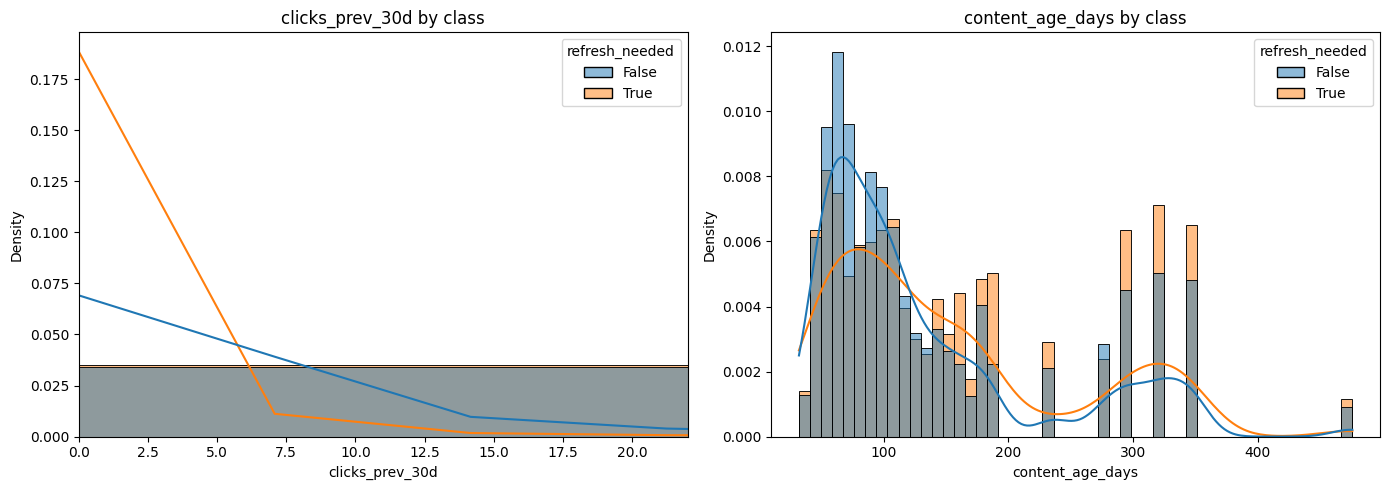

In [40]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Example plot
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(data=sample_data, x='clicks_prev_30d', hue='refresh_needed',
             bins=50, kde=True, ax=axes[0], stat='density', common_norm=False)
axes[0].set_title('clicks_prev_30d by class')
axes[0].set_xlim(0, sample_data['clicks_prev_30d'].quantile(0.95))  # trim outliers for visibility

sns.histplot(data=sample_data, x='content_age_days', hue='refresh_needed',
             bins=50, kde=True, ax=axes[1], stat='density', common_norm=False)
axes[1].set_title('content_age_days by class')

plt.tight_layout()
plt.show()

**Conclusion**<br>
Since neither clicks nor age can separate the two groups with a straight vertical line, we need ML to look at the interaction between these variables simultaneously.

## Self-check

Before you submit, confirm each line honestly:

- [✓] Every section above is filled — markdown thinking AND the code that backs it
- [✓] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✓] No client names, URLs, or private queries anywhere
- [✓] My claims use careful words: observed, measured, directional, decision-support
- [✓] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.